In [8]:
from sklearn import datasets
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

## Lets load the Diabetes dataset

In [9]:
diabetes = datasets.load_diabetes()

In [10]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [11]:
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

## Preparing The Dataset

In [12]:
df = pd.DataFrame(X, columns=feature_names)
df['Progression'] = y

In [13]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [14]:
df = df.drop(["sex"], axis=1)
df.head()

,age,bmi,bp,s1,s2,s3,s4,s5,s6,Progression
0,0.038076,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          442 non-null    float64
 1   bmi          442 non-null    float64
 2   bp           442 non-null    float64
 3   s1           442 non-null    float64
 4   s2           442 non-null    float64
 5   s3           442 non-null    float64
 6   s4           442 non-null    float64
 7   s5           442 non-null    float64
 8   s6           442 non-null    float64
 9   Progression  442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [16]:
## Check the missing Values
df.isnull().sum()

age            0
bmi            0
bp             0
s1             0
s2             0
s3             0
s4             0
s5             0
s6             0
Progression    0
dtype: int64

## Train Test Split


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [18]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [19]:
X_train=scaler.fit_transform(X_train)

In [20]:
X_test=scaler.transform(X_test)

## Model Training

In [21]:
from sklearn.linear_model import LinearRegression

regression=LinearRegression()

In [22]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 1.35,-12.45, 26.21,..., 13.96, 31.58, 1.98]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,153.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[34.97,21.32,19.7 ,...,11.6 , 4.88, 1.71]"


In [23]:
## print the coefficients and the intercept
print(regression.coef_)

[  1.35246724 -12.45426893  26.21004615  18.61443344 -43.26039442
  24.2556288    5.73862584  13.96342685  31.57521526   1.98339354]


In [24]:
print(regression.intercept_)

153.90291262135923


In [27]:
### Prediction With Test Data
reg_pred = regression.predict(X_test)

## Assumptions

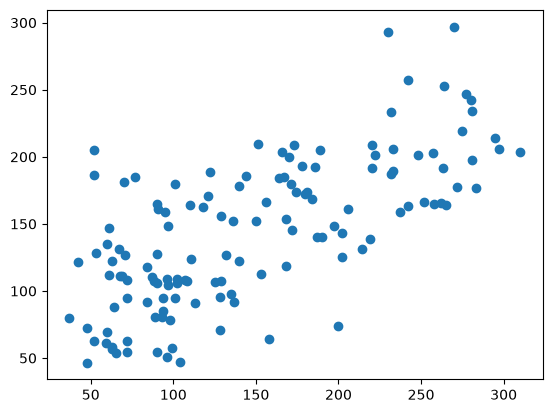

In [28]:
## plot a scatter plot for the prediction
plt.scatter(y_test, reg_pred)

In [29]:
## Residuals
residuals = y_test-reg_pred

In [30]:
residuals

array([  80.53029969, -111.10052342,   76.65599096,  -62.75977277,
        -12.8830531 ,   -7.89830434,  -15.26463123,   94.23830682,
          9.01450294,  -13.15960992,   -0.4855284 ,   85.86764892,
         41.59257498,   90.86102646,   37.2188158 ,  -64.00472765,
         80.70210028,   11.47092339,  -29.66656381,   55.50014366,
        106.76328683,  -24.00656925,   57.34891541,   45.07766573,
        -26.81266751,  -44.81022205,   71.06864294, -107.72924276,
          1.37079171,   -1.26566599,  -38.14743952,   21.64934995,
        -37.72125745,  -20.04205666,    7.76200103,   43.48451137,
        -79.83265708,  -33.75339206,   26.32049694,    4.42436599,
        -24.55421321,    0.72428895,  -10.15280313,   14.70660016,
        -75.19282154,  -10.95752038,  126.41090551,  -23.05656189,
         35.50276646,   93.11079368,  -16.49472803,   94.1125435 ,
        -42.4354561 ,  -36.34936269,   -8.96973311,  -63.70054112,
        -23.04833555,  -58.68990406,   49.62643481,   -9.69946

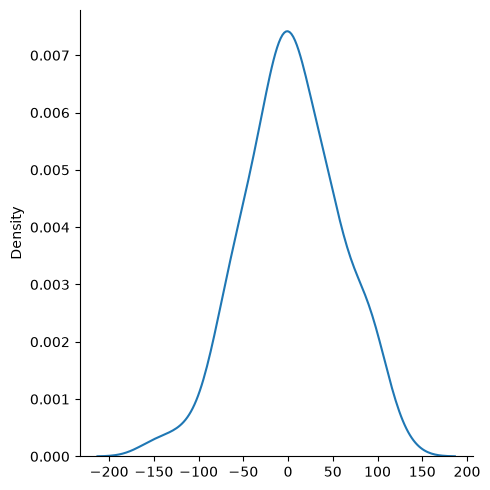

In [31]:
## Plot this residuals 

sns.displot(residuals, kind="kde")

In [32]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, pred))
print(mean_squared_error(y_test, pred))
print(np.sqrt(mean_squared_error(y_test, pred)))

41.91937845679274
2821.7509810013116
53.12015607094271


## R square and adjusted R square


Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares


In [33]:
from sklearn.metrics import r2_score
score=r2_score(y_test, reg_pred)
print(score)

0.4772897164322616


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [34]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.43444461122179123

## New Data Prediction

In [35]:
new = diabetes.data[0].reshape(1, -1)

In [36]:
new_scaled = scaler.transform(new)

In [37]:
pred_new = regression.predict(new_scaled)

In [38]:
pred_new[0]

np.float64(209.68990406336002)

## Pickling The Model file For Deployment

In [39]:
import pickle

In [ ]:
# pickle.dump(regression,open('regmodel.pkl','wb'))

In [ ]:

# pickle.dump(scaler,open('scaling.pkl','wb'))